##Модель: deepvk/bert-base-uncased

##Датасет: CEDR (Corpus for Emotions Detecting in Russian)

##Суть: Предложения из ЖЖ, новостей Ленты.ру и Твиттера.

##Классы (5 штук):

Радость

Печаль

Удивление

Страх

Гнев

In [9]:
# Устанавливаем совместимые версии для Python 3.12
!pip uninstall transformers tensorflow -y

# Устанавливаем последнюю стабильную версию TensorFlow (2.19.0 уже была)
!pip install tensorflow==2.19.0
!pip install transformers==4.46.0  # более новая версия, совместимая с TF 2.19
!pip install datasets evaluate scikit-learn
!pip install tf-keras  # иногда требуется для совместимости

# Перезапускаем runtime
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

Found existing installation: transformers 4.36.2
Uninstalling transformers-4.36.2:
  Successfully uninstalled transformers-4.36.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.8 MB/s eta 0:00:00


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.3 MB/s eta 0:00:00
Reason for being yanked: This version unfortunately does not work with 3.8 but we did not drop the support yet
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 121.3 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.15.2
    Uninstalling tokenizers-0.15.2:
      Successfully uninstalled tokenizers-0.15.2


{'status': 'ok', 'restart': True}

#0. Библиотеки

In [1]:
import tensorflow as tf
from transformers import (
    TFAutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    create_optimizer
)
from datasets import load_dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем датасет CEDR

In [2]:
print("Загружаем датасет CEDR...")
dataset = load_dataset("cedr", "main")

print(f"Размер train: {len(dataset['train'])}")
print(f"Размер test: {len(dataset['test'])}")

Загружаем датасет CEDR...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/757k [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/188k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7528 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1882 [00:00<?, ? examples/s]

Размер train: 7528
Размер test: 1882


# 2. Маппинг эмоций

In [4]:
id2label = {0: "радость", 1: "грусть", 2: "удивление", 3: "страх", 4: "гнев"}
label2id = {v: k for k, v in id2label.items()}


# 3. Загружаем модель и токенизатор

In [5]:
model_name = "deepvk/bert-base-uncased"
print(f"Загружаем модель {model_name}...")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = TFAutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5,
    id2label=id2label,
    label2id=label2id,
    from_pt=True  # конвертируем PyTorch веса в TensorFlow
)

Загружаем модель deepvk/bert-base-uncased...


tokenizer_config.json:   0%|          | 0.00/332 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/669 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/455M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# 4. Функция для подготовки данных

In [6]:
def prepare_data(examples):
    # Токенизируем
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="np"
    )

    # Метки (берем первую эмоцию)
    labels = [label[0] for label in examples["labels"]]

    return {
        "input_ids": tokenized["input_ids"],
        "attention_mask": tokenized["attention_mask"],
        "labels": labels
    }

# 5. Подготавливаем данные

In [8]:
print("Подготавливаем данные...")

def prepare_data(examples):
    # Токенизируем
    tokenized = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="np"
    )

    # Метки - обрабатываем случай пустых списков
    labels = []
    for label_list in examples["labels"]:
        if len(label_list) > 0:
            labels.append(label_list[0])  # берем первую эмоцию
        else:
            labels.append(-1)  # или можно назначить нейтральный класс, но лучше пропустить

    return {
        "input_ids": tokenized["input_ids"],
        "attention_mask": tokenized["attention_mask"],
        "labels": labels
    }

# Применяем функцию
train_data = dataset["train"].map(
    prepare_data,
    batched=True,
    batch_size=1000,
    remove_columns=dataset["train"].column_names
)

test_data = dataset["test"].map(
    prepare_data,
    batched=True,
    batch_size=1000,
    remove_columns=dataset["test"].column_names
)

# Проверяем, есть ли примеры с меткой -1
train_labels = train_data["labels"]
print(f"Всего примеров в train: {len(train_labels)}")
print(f"Примеров с пустой меткой: {sum(1 for l in train_labels if l == -1)}")

# Удаляем примеры с пустыми метками, если они есть
if -1 in train_labels:
    print("Удаляем примеры с пустыми метками из train...")
    train_data = train_data.filter(lambda x: x["labels"] != -1)

if -1 in test_data["labels"]:
    print("Удаляем примеры с пустыми метками из test...")
    test_data = test_data.filter(lambda x: x["labels"] != -1)

print(f"Train после очистки: {len(train_data)}")
print(f"Test после очистки: {len(test_data)}")

# Проверяем распределение классов
print("\nРаспределение классов в train:")
unique, counts = np.unique(train_data["labels"], return_counts=True)
for label_id, count in zip(unique, counts):
    print(f"  {id2label[label_id]}: {count} ({count/len(train_data)*100:.1f}%)")

Подготавливаем данные...


Map:   0%|          | 0/7528 [00:00<?, ? examples/s]

Map:   0%|          | 0/1882 [00:00<?, ? examples/s]

Всего примеров в train: 7528
Примеров с пустой меткой: 3043
Удаляем примеры с пустыми метками из train...


Filter:   0%|          | 0/7528 [00:00<?, ? examples/s]

Удаляем примеры с пустыми метками из test...


Filter:   0%|          | 0/1882 [00:00<?, ? examples/s]

Train после очистки: 4485
Test после очистки: 1148

Распределение классов в train:
  радость: 1548 (34.5%)
  грусть: 1403 (31.3%)
  удивление: 574 (12.8%)
  страх: 570 (12.7%)
  гнев: 390 (8.7%)


# 6. Создаем tf.data.Dataset

In [9]:
def create_tf_dataset(hf_dataset, batch_size=16, shuffle=True):
    input_ids = np.array(hf_dataset["input_ids"])
    attention_mask = np.array(hf_dataset["attention_mask"])
    labels = np.array(hf_dataset["labels"])

    dataset = tf.data.Dataset.from_tensor_slices((
        {
            "input_ids": input_ids,
            "attention_mask": attention_mask
        },
        labels
    ))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(labels))

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 2e-5

train_dataset = create_tf_dataset(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataset = create_tf_dataset(test_data, batch_size=BATCH_SIZE, shuffle=False)


# 7. Компилируем модель

In [11]:
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metrics = ['accuracy']

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

print("Модель скомпилирована")

Модель скомпилирована


# 8. Колбэки

In [12]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

# 9. Обучение

In [13]:
print("Начинаем обучение...")
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)

Начинаем обучение...
Epoch 1/5
281/281 [==============================] - 199s 508ms/step - loss: 0.7273 - accuracy: 0.7489 - val_loss: 0.4441 - val_accuracy: 0.8510
Epoch 2/5
281/281 [==============================] - 136s 486ms/step - loss: 0.2796 - accuracy: 0.9090 - val_loss: 0.3924 - val_accuracy: 0.8659
Epoch 3/5
281/281 [==============================] - 136s 485ms/step - loss: 0.1291 - accuracy: 0.9594 - val_loss: 0.4705 - val_accuracy: 0.8476
Epoch 4/5
281/281 [==============================] - 136s 483ms/step - loss: 0.0539 - accuracy: 0.9824 - val_loss: 0.5428 - val_accuracy: 0.8519
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.


# 10. Визуализация обучения

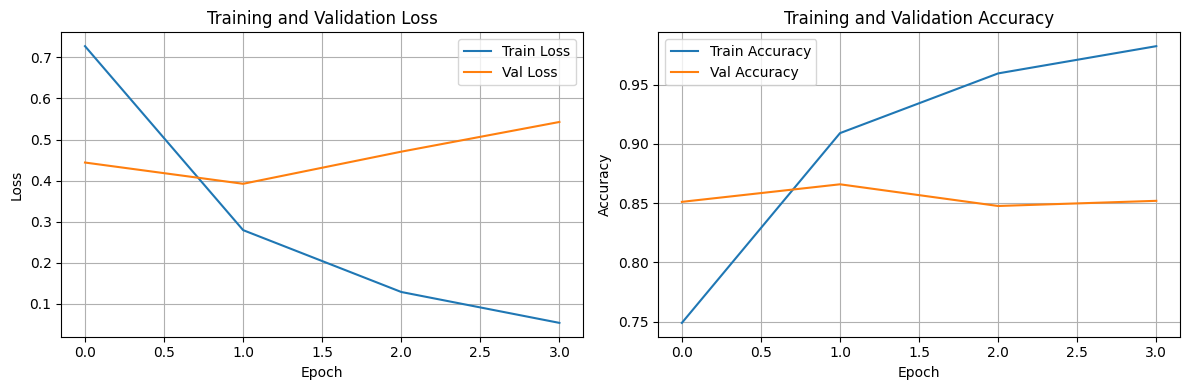

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# 11. Оценка на тесте

In [16]:
print("\n" + "="*60)
print("ОЦЕНКА МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)

y_true = []
y_pred = []

for batch in test_dataset:
    inputs, labels = batch
    logits = model(inputs, training=False).logits
    predictions = tf.argmax(logits, axis=-1)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions.numpy())

# Метрики
accuracy = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")

print("\nДетальный отчет:")
print(classification_report(y_true, y_pred, target_names=list(id2label.values())))


ОЦЕНКА МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ
Accuracy: 0.8659
F1 Macro: 0.8460
F1 Weighted: 0.8663

Детальный отчет:
              precision    recall  f1-score   support

     радость       0.94      0.88      0.91       347
      грусть       0.87      0.90      0.88       378
   удивление       0.85      0.83      0.84       165
       страх       0.83      0.85      0.84       136
        гнев       0.75      0.78      0.76       122

    accuracy                           0.87      1148
   macro avg       0.85      0.85      0.85      1148
weighted avg       0.87      0.87      0.87      1148



# 12. Confusion Matrix

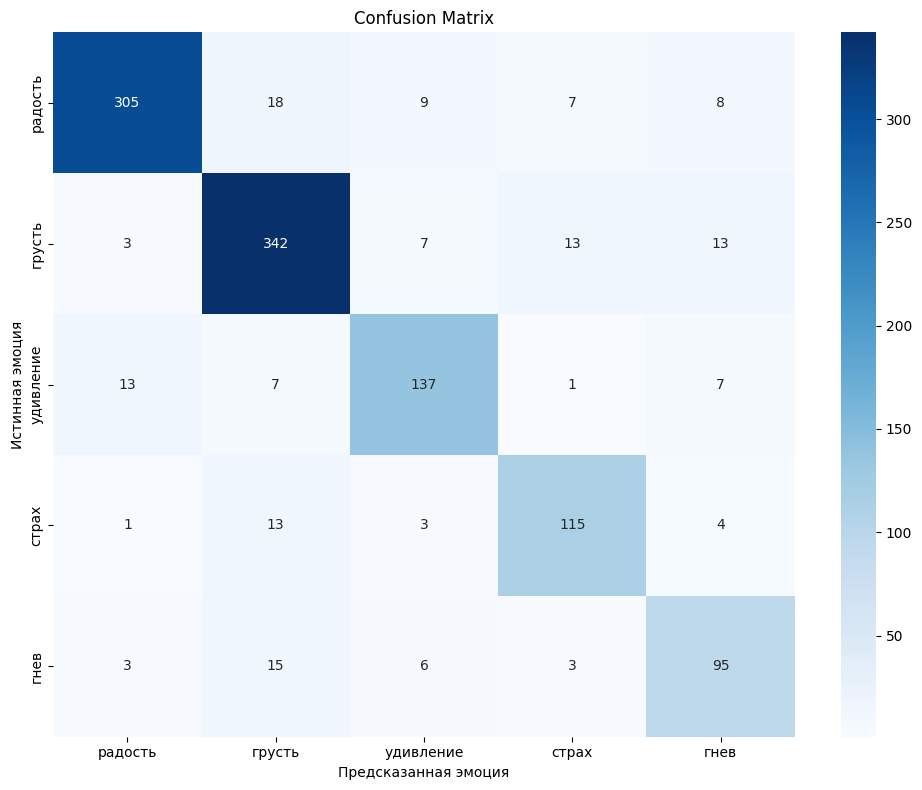

In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(id2label.values()),
            yticklabels=list(id2label.values()))
plt.xlabel('Предсказанная эмоция')
plt.ylabel('Истинная эмоция')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#13. ДЕМОНСТРАЦИЯ 5 ПРИМЕРОВ

In [19]:
print("\n" + "="*60)
print("ПРИМЕРЫ ПРЕДСКАЗАНИЙ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)

# Получаем оригинальные данные
test_texts = dataset["test"]["text"]
test_sources = dataset["test"]["source"]

# Создаем список валидных меток (только те, у которых есть значение)
valid_labels = []
valid_indices = []

for i, label_list in enumerate(dataset["test"]["labels"]):
    if len(label_list) > 0:  # если метка не пустая
        valid_labels.append(label_list[0])
        valid_indices.append(i)

print(f"Всего примеров в тесте: {len(dataset['test']['labels'])}")
print(f"Валидных примеров (с метками): {len(valid_indices)}")
print(f"Предсказаний получено: {len(y_pred)}")

# Проверяем, что размеры совпадают
assert len(valid_indices) == len(y_pred), "Количество валидных примеров должно совпадать с количеством предсказаний!"

# Выбираем 5 случайных индексов из валидных
np.random.seed(42)
sample_positions = np.random.choice(len(valid_indices), size=5, replace=False)

print("\n" + "-" * 60)
for pos in sample_positions:
    # Получаем оригинальный индекс в датасете
    original_idx = valid_indices[pos]

    # Получаем данные
    text = test_texts[original_idx]
    source = test_sources[original_idx]
    true_label = id2label[valid_labels[pos]]  # метка из валидного списка
    pred_label = id2label[y_pred[pos]]        # предсказание для этой позиции

    # Обрезаем текст если слишком длинный
    if len(text) > 200:
        display_text = text[:200] + "..."
    else:
        display_text = text

    print(f"Текст: {display_text}")
    print(f"Источник: {source}")
    print(f"Истинная эмоция: {true_label}")
    print(f"Предсказанная эмоция: {pred_label}")
    print(f"Результат: {'✓' if true_label == pred_label else '✗'}")
    print("-" * 60)

# Также покажем распределение предсказаний
print("\nРаспределение предсказанных эмоций:")
unique_pred, counts_pred = np.unique(y_pred, return_counts=True)
for label_id, count in zip(unique_pred, counts_pred):
    print(f"  {id2label[label_id]}: {count} ({count/len(y_pred)*100:.1f}%)")


ПРИМЕРЫ ПРЕДСКАЗАНИЙ НА ТЕСТОВОЙ ВЫБОРКЕ
Всего примеров в тесте: 1882
Валидных примеров (с метками): 1148
Предсказаний получено: 1148

------------------------------------------------------------
Текст: Так вот почему он такой злой - он в нашей школе учился)))
Источник: twitter
Истинная эмоция: радость
Предсказанная эмоция: радость
Результат: ✓
------------------------------------------------------------
Текст: Потом пришлось ждать 30м тётю,пока она за мной не приедит,сижу в машине,ничего не чувствую,замёрзла до ужаса ((
Источник: twitter
Истинная эмоция: грусть
Предсказанная эмоция: грусть
Результат: ✓
------------------------------------------------------------
Текст: Как же можно быть таким злым человеком?!
Источник: twitter
Истинная эмоция: удивление
Предсказанная эмоция: гнев
Результат: ✗
------------------------------------------------------------
Текст: – изумился Старший Жирный .
Источник: lj
Истинная эмоция: удивление
Предсказанная эмоция: удивление
Результат: ✓
-------------